In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

df = pd.read_csv("../data/processed/telco_clean.csv").set_index("CustomerID")
pred = pd.read_csv("../data/processed/test_predictions.csv", index_col="CustomerID")

econ = pred.join(df[["CLTV", "Monthly Charges"]])
print(econ.shape, econ.isna().sum().sum())

(1409, 4) 0


In [2]:
addressable = ["Competitor offered higher download speeds", "Competitor offered more data",
               "Competitor made better offer", "Competitor had better devices", "Price too high",
               "Extra data charges", "Long distance charges", "Lack of affordable download/upload speed"]
service = ["Attitude of support person", "Attitude of service provider", "Network reliability",
           "Product dissatisfaction", "Service dissatisfaction", "Lack of self-service on Website",
           "Limited range of services", "Poor expertise of phone support", "Poor expertise of online support"]

reasons = df.loc[df["Churn Value"] == 1, "Churn Reason"]
groups = reasons.map(lambda r: "Price/offer" if r in addressable
                     else ("Service quality" if r in service else "Unsavable/unknown"))
print(groups.value_counts())
print((groups.value_counts(normalize=True) * 100).round(1))

Churn Reason
Price/offer          864
Service quality      792
Unsavable/unknown    213
Name: count, dtype: int64
Churn Reason
Price/offer          46.2
Service quality      42.4
Unsavable/unknown    11.4
Name: proportion, dtype: float64


In [3]:
CALL_COST = 5.0          # cost of one retention call ($)
DISCOUNT_PCT = 0.20      # offer: 20% off the monthly bill
DISCOUNT_MONTHS = 6      # ... for 6 months
SUCCESS_RATE = 0.25      # chance the offer saves a customer who would leave
MARGIN = 0.30            # share of CLTV that is profit

In [4]:
econ["cost"] = CALL_COST + DISCOUNT_PCT * DISCOUNT_MONTHS * econ["Monthly Charges"]
econ["value_saved"] = MARGIN * econ["CLTV"]
econ["ev"] = econ["churn_probability"] * SUCCESS_RATE * econ["value_saved"] - econ["cost"]
econ["realized"] = econ["churn_actual"] * SUCCESS_RATE * econ["value_saved"] - econ["cost"]

print("Average cost per customer:", round(econ["cost"].mean(), 1))
print("Average value saved:", round(econ["value_saved"].mean()))
print("Customers with positive EV:", (econ["ev"] > 0).sum(), f"({(econ['ev'] > 0).mean():.1%})")
print("Expected profit, contact everyone:", round(econ["ev"].sum()))
print("Realized profit, contact everyone:", round(econ["realized"].sum()))

Average cost per customer: 81.9
Average value saved: 1316
Customers with positive EV: 576 (40.9%)
Expected profit, contact everyone: 554
Realized profit, contact everyone: -812


In [5]:
K = 100
by_prob = econ.sort_values("churn_probability", ascending=False).head(K)
by_ev = econ.sort_values("ev", ascending=False).head(K)
print("Customers in both lists:", len(set(by_prob.index) & set(by_ev.index)))

def campaign_summary(name, d):
    spend = d["cost"].sum()
    gross = (d["churn_actual"] * SUCCESS_RATE * d["value_saved"]).sum()
    net = gross - spend
    print(f"{name}: spend ${spend:,.0f} | value saved ${gross:,.0f} | net profit ${net:,.0f} | ROI {net/spend:.1%}")

campaign_summary("Top 100 by churn probability", by_prob)
campaign_summary("Top 100 by expected value  ", by_ev)

rand_spend = K * econ["cost"].mean()
rand_gross = K * (econ["churn_actual"] * SUCCESS_RATE * econ["value_saved"]).mean()
print(f"Random 100 (average)        : spend ${rand_spend:,.0f} | value saved ${rand_gross:,.0f} "
      f"| net profit ${rand_gross - rand_spend:,.0f} | ROI {(rand_gross - rand_spend)/rand_spend:.1%}")

Customers in both lists: 50
Top 100 by churn probability: spend $10,024 | value saved $24,509 | net profit $14,485 | ROI 144.5%
Top 100 by expected value  : spend $9,053 | value saved $27,464 | net profit $18,412 | ROI 203.4%
Random 100 (average)        : spend $8,191 | value saved $8,133 | net profit $-58 | ROI -0.7%


In [6]:
print(by_prob[["churn_probability", "CLTV", "cost"]].mean().round(2))
print(by_ev[["churn_probability", "CLTV", "cost"]].mean().round(2))

churn_probability       0.80
CLTV                 3901.22
cost                  100.24
dtype: float64
churn_probability       0.72
CLTV                 5048.84
cost                   90.53
dtype: float64


In [7]:
by_prob[by_prob["ev"] <= 0][["churn_probability", "CLTV", "Monthly Charges", "cost", "value_saved", "ev"]].round(2)

,churn_probability,CLTV,Monthly Charges,cost,value_saved,ev
CustomerID,,,,,,
8884-ADFVN,0.83,2016,101.95,127.34,604.8,-1.9


In [8]:
thresholds = np.round(np.arange(0.0, 0.96, 0.01), 2)
rows = []
for t in thresholds:
    chosen = econ[econ["churn_probability"] >= t]
    rows.append({"threshold": t, "contacted": len(chosen),
                 "expected_profit": chosen["ev"].sum(),
                 "realized_profit": chosen["realized"].sum()})
curve = pd.DataFrame(rows)

best = curve.loc[curve["expected_profit"].idxmax()]
best

threshold              0.230000
contacted            625.000000
expected_profit    39579.226553
realized_profit    36845.785000
Name: 23, dtype: float64

In [9]:
precision, recall, thr = precision_recall_curve(econ["churn_actual"], econ["churn_probability"])
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
f1_threshold = thr[np.argmax(f1)]
print("F1-optimal threshold:", round(f1_threshold, 3))

for label, t in [("Threshold 0.5", 0.5), ("F1-optimal", f1_threshold), ("Profit-optimal", best["threshold"])]:
    chosen = econ[econ["churn_probability"] >= t]
    print(f"{label:15s} t={t:.2f} | contacted {len(chosen):>3} | "
          f"expected ${chosen['ev'].sum():,.0f} | realized ${chosen['realized'].sum():,.0f}")

chosen = econ[econ["ev"] > 0]
print(f"{'EV > 0 rule':15s} contacted {len(chosen):>3} | "
      f"expected ${chosen['ev'].sum():,.0f} | realized ${chosen['realized'].sum():,.0f}")

F1-optimal threshold: 0.344
Threshold 0.5   t=0.50 | contacted 311 | expected $30,764 | realized $28,826
F1-optimal      t=0.34 | contacted 485 | expected $37,100 | realized $34,053
Profit-optimal  t=0.23 | contacted 625 | expected $39,579 | realized $36,846
EV > 0 rule     contacted 576 | expected $43,285 | realized $41,498


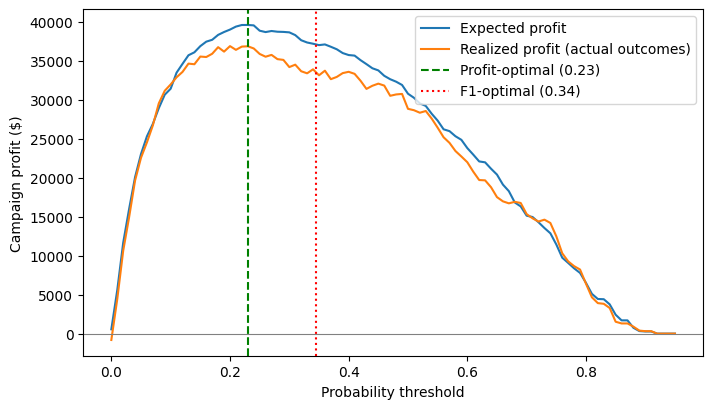

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curve["threshold"], curve["expected_profit"], label="Expected profit")
ax.plot(curve["threshold"], curve["realized_profit"], label="Realized profit (actual outcomes)")
ax.axvline(best["threshold"], color="green", linestyle="--", label=f"Profit-optimal ({best['threshold']:.2f})")
ax.axvline(f1_threshold, color="red", linestyle=":", label=f"F1-optimal ({f1_threshold:.2f})")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Campaign profit ($)")
ax.legend()
plt.savefig("../reports/profit_vs_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
ranked = econ.sort_values("ev", ascending=False)
for k in [50, 100, 200, 300, 400, 576]:
    d = ranked.head(k)
    spend = d["cost"].sum()
    net = (d["churn_actual"] * SUCCESS_RATE * d["value_saved"]).sum() - spend
    print(f"Contact {k:>3}: spend ${spend:>7,.0f} | net profit ${net:>7,.0f} | ROI {net/spend:.1%}")

Contact  50: spend $  4,653 | net profit $  9,911 | ROI 213.0%
Contact 100: spend $  9,053 | net profit $ 18,412 | ROI 203.4%
Contact 200: spend $ 17,643 | net profit $ 28,724 | ROI 162.8%
Contact 300: spend $ 25,745 | net profit $ 36,430 | ROI 141.5%
Contact 400: spend $ 33,807 | net profit $ 39,944 | ROI 118.2%
Contact 576: spend $ 48,100 | net profit $ 41,498 | ROI 86.3%


In [12]:
rows = []
for s in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    row = {"Success rate": s}
    for m in [0.20, 0.30, 0.40]:
        ev = econ["churn_probability"] * s * (m * econ["CLTV"]) - econ["cost"]
        row[f"Margin {m:.0%}"] = f"${ev.clip(lower=0).sum():,.0f} ({(ev > 0).sum()} customers)"
    rows.append(row)
pd.DataFrame(rows).set_index("Success rate")

,Margin 20%,Margin 30%,Margin 40%
Success rate,,,
0.10,$378 (34 customers),"$2,640 (146 customers)","$8,253 (265 customers)"
0.15,"$2,640 (146 customers)","$11,987 (315 customers)","$26,013 (460 customers)"
0.20,"$8,253 (265 customers)","$26,013 (460 customers)","$49,470 (605 customers)"
0.25,"$16,259 (372 customers)","$43,285 (576 customers)","$75,284 (670 customers)"
0.30,"$26,013 (460 customers)","$62,231 (645 customers)","$102,303 (731 customers)"
0.40,"$49,470 (605 customers)","$102,303 (731 customers)","$158,460 (823 customers)"


In [13]:
def breakeven(d):
    return d["cost"].sum() / (d["churn_actual"] * d["value_saved"]).sum()

print(round(breakeven(by_ev), 3), round(breakeven(by_prob), 3), round(breakeven(econ), 3))

0.082 0.102 0.252


In [14]:
econ.round(4).to_csv("../data/processed/economics.csv")
econ.shape

(1409, 8)